In [93]:

!pip -q install xgboost

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
#from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from category_encoders import TargetEncoder

import time
import seaborn as sns

from cycler import cycler
theme = {
    "figure_bg": "#02030D",
    "axes_bg":   "#26262F",
    "text":      "#E7D8DE",
    "muted":     "#B7AEB8",
    "grid":      "#4A4C59",
    "spine":     "#5A5D6B",
    "purple":    "#B07CF8",
    "blue":      "#8ED6F8",
    "lavender":  "#9EA8FF",
}

plt.rcParams.update({
    "figure.facecolor": theme["figure_bg"],
    "axes.facecolor": theme["axes_bg"],
    "axes.edgecolor": theme["spine"],
    "axes.labelcolor": theme["text"],
    "axes.titlecolor": theme["lavender"],
    "xtick.color": theme["muted"],
    "ytick.color": theme["muted"],
    "grid.color": theme["grid"],
    "text.color": theme["text"],
    "legend.facecolor": theme["axes_bg"],
    "legend.edgecolor": theme["spine"],
    "legend.labelcolor": theme["text"],
    "savefig.facecolor": theme["figure_bg"],
    "savefig.edgecolor": theme["figure_bg"],
    "axes.prop_cycle": cycler(color=[
        theme["purple"],
        theme["blue"],
        theme["lavender"],
        "#C9A7FF",
        "#A5E3FF"
    ])
})

timestamp = time.strftime("%m_%d_%H_%M_%S", time.localtime())
#joblib.dump(result, f'{name}_{timestamp}.pkl')
folder = f"./content_{timestamp}"
print(folder)
!mkdir -p {folder}

ready_to_model = True  # "yes" or "no"


./content_04_04_08_22_31


# Phase 2

In [95]:
df = pd.read_csv("housing_resized.csv")
start_size = len(df)
print(f"Initial dataset size: {start_size}")

Initial dataset size: 384977


In [96]:
def summary_table(df, categorical_cols=None):
    if categorical_cols is None:
        categorical_cols = []

    summary = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.values,
        "Non-Null Count": df.notnull().sum().values,
        "Missing Values": df.isnull().sum().values,
        "Missing %": ((df.isnull().sum() / len(df)) * 100).values
    })

    if categorical_cols is not None:
        summary["Num Categories"] = [
            df[col].nunique(dropna=False) if col in categorical_cols else None
            for col in df.columns
        ]


    return summary

In [97]:
total_duplicates = df.duplicated().sum()
id_duplicates = df.duplicated(subset=["id"]).sum()
print(f"There are {total_duplicates} duplicate rows in the dataset.")
print(f"There are {id_duplicates} duplicate values based on the 'id' column.")

count = (df["state"].astype(str).str.len() > 2).sum()
print(f"There are {count} rows where 'state' is more than 2 characters long.")

def summary_table_2(df):
    summary = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.values,
        "Non-Null Count": df.notnull().sum().values,
        "Missing Values": df.isnull().sum().values,
        "Missing %": ((df.isnull().sum() / len(df)) * 100).values
    })
    return summary
summary_table_1 = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.notnull().sum().values,
    "Missing Values": df.isnull().sum().values,
    "Missing %": ((df.isnull().sum() / start_size) * 100).values
})

categorical_cols = ["region","type","cats_allowed", "dogs_allowed", 
                    "smoking_allowed", "wheelchair_access", "electric_vehicle_charge", 
                    "comes_furnished", "laundry_options", "parking_options", "state", ]
display(summary_table(df, categorical_cols))
#display(summary_table(df),None)

display(df.describe())

There are 0 duplicate rows in the dataset.
There are 0 duplicate values based on the 'id' column.
There are 0 rows where 'state' is more than 2 characters long.


,Column,Data Type,Non-Null Count,Missing Values,Missing %,Num Categories
0,id,int64,384977,0,0.000000,NaN
1,region,str,384977,0,0.000000,404.0
2,price,int64,384977,0,0.000000,NaN
3,type,str,384977,0,0.000000,12.0
4,sqfeet,int64,384977,0,0.000000,NaN
5,beds,int64,384977,0,0.000000,NaN
6,baths,float64,384977,0,0.000000,NaN
7,cats_allowed,int64,384977,0,0.000000,2.0
8,dogs_allowed,int64,384977,0,0.000000,2.0
9,smoking_allowed,int64,384977,0,0.000000,2.0


,id,price,sqfeet,beds,baths,cats_allowed,dogs_allowed,smoking_allowed,wheelchair_access,electric_vehicle_charge,comes_furnished,lat,long
count,3.849770e+05,3.849770e+05,3.849770e+05,384977.000000,384977.000000,384977.000000,384977.000000,384977.000000,384977.000000,384977.000000,384977.000000,383059.000000,383059.000000
mean,7.040982e+09,8.825722e+03,1.059900e+03,1.905345,1.480718,0.726890,0.707918,0.731771,0.082111,0.012871,0.048128,37.233487,-92.700631
std,8.800376e+06,4.462200e+06,1.915076e+04,3.494572,0.618061,0.445557,0.454721,0.443038,0.274535,0.112718,0.214036,5.546171,16.531980
min,7.003808e+09,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-43.533300,-163.894000
25%,7.035979e+09,8.050000e+02,7.500000e+02,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,33.454700,-100.775000
50%,7.043320e+09,1.036000e+03,9.490000e+02,2.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,37.647800,-87.745100
75%,7.048426e+09,1.395000e+03,1.150000e+03,2.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,41.138300,-81.179600
max,7.051292e+09,2.768307e+09,8.388607e+06,1100.000000,75.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,102.036000,172.633000


In [98]:
def map_show_1(df):
    plt.figure(figsize=(10, 6), facecolor="#FFF2CC")
    plt.scatter(df["long"], df["lat"], alpha=0.3, s=10)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Housing Listing Locations (Longitude vs Latitude)")
    plt.tight_layout()
    plt.show()




def map_show(df):
    fig, ax = plt.subplots(figsize=(10, 6), facecolor=theme["figure_bg"])
    ax.set_facecolor(theme["axes_bg"])

    ax.scatter(
        df["long"], df["lat"],
        color=theme["blue"],
        alpha=0.35,
        s=10
    )

    ax.set_title("Housing Listing Locations (Longitude vs Latitude)", pad=12)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.grid(True, alpha=0.25)

    for spine in ax.spines.values():
        spine.set_color(theme["spine"])

    plt.tight_layout()
    plt.show()

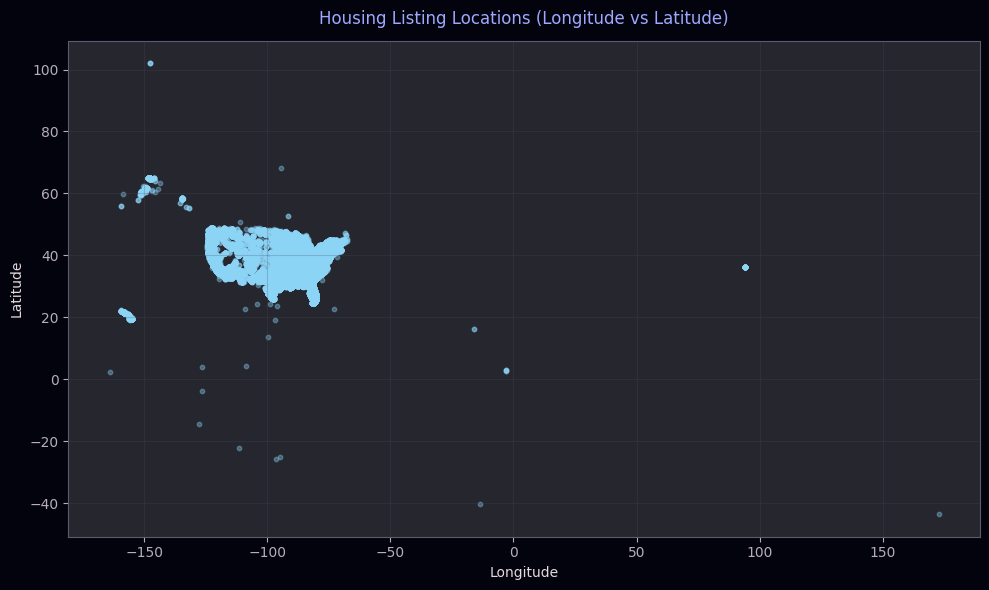

In [99]:
map_show(df)

# Phase 3

In [100]:
#Task 3.1 : Selecting Data…
df_selected = df.drop(columns=['id', 'url', 'image_url', 'description'], errors='ignore')
#df_selected



In [101]:
def check_outliers_multiple(df, cutoffs):
    results = {}
    outliers_sum = 0
    for column, (low_cutoff, high_cutoff) in cutoffs.items():
        outliers = df[(df[column] < low_cutoff) | (df[column] > high_cutoff)]
        results[column] = len(outliers)
        outliers_sum += len(outliers)

    results["total"] = outliers_sum
    return results

cutoffs = {
    "price": (1, max(df["price"])),
    "sqfeet": (70, max(df["sqfeet"]))
}

outlier_counts = check_outliers_multiple(df_selected, cutoffs)
print(outlier_counts)

print(f"These properties represent {(outlier_counts['total'] / start_size) * 100:.2f}% of the dataset.")


{'price': 1307, 'sqfeet': 929, 'total': 2236}
These properties represent 0.58% of the dataset.


Rows before: 384977, after: 382787, removed: 2190 (0.57%)


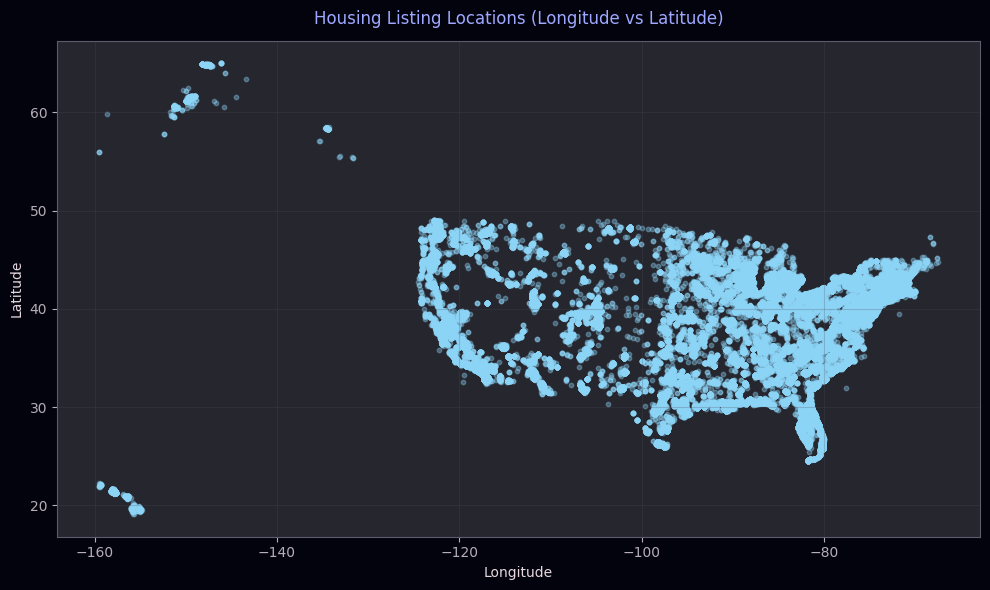

CONUS Applied per-region IQR filtering on price.
Rows before: 382787, after: 364084, removed: 18703 (4.89%)
STATE Applied per-region IQR filtering on price.
Rows before: 382787, after: 363371, removed: 19416 (5.07%)
REGION Applied per-region IQR filtering on price.
Rows before: 382787, after: 362781, removed: 20006 (5.23%)


,Column,Data Type,Non-Null Count,Missing Values,Missing %,Num Categories
0,region,str,362781,0,0.000000,None
1,price,int64,362781,0,0.000000,None
2,type,str,362781,0,0.000000,None
3,sqfeet,int64,362781,0,0.000000,None
4,beds,int64,362781,0,0.000000,None
5,baths,float64,362781,0,0.000000,None
6,cats_allowed,int64,362781,0,0.000000,None
7,dogs_allowed,int64,362781,0,0.000000,None
8,smoking_allowed,int64,362781,0,0.000000,None
9,wheelchair_access,int64,362781,0,0.000000,None


In [102]:
# Task 3.2 : Cleaning Data…

clean_long_lat = True

if clean_long_lat == True:
    before = start_size

    # CONUS
    conus_mask = (
        df_selected["lat"].between(25, 49.5) &
        df_selected["long"].between(-125, -66.5)
    )

    # Alaska + Hawaii box
    ak_hi_mask = (
        df_selected["lat"].between(18, 66) &
        df_selected["long"].between(-160.5, -130)
    )

    # South Florida override box
    south_fl_mask = (
        df_selected["lat"].between(23, 26) &
        df_selected["long"].between(-83, -79)
    )

    # Keep anything inside at least one valid box
    keep_mask = conus_mask | ak_hi_mask | south_fl_mask

    df_cleaned = df_selected[keep_mask].copy()
    after = len(df_cleaned)

    print(
        f"Rows before: {before}, after: {after}, removed: {before - after} "
        f"({(before - after) / before:.2%})"
    )

map_show(df_cleaned)



# ------------------------------
# 2) Target / features
# ------------------------------
TARGET = "price"

# -----------------------------------
# IQR option
# Valid options: "NONE", "CONUS", "STATE", "REGION"
# -----------------------------------


I = 1.5  # IQR multiplier
z = 1.72 # z-score
k= I

def clean_outliers(
    df,
    TARGET='price',
    scope="CONUS",
    k=1.5#,
    #z_thresh=3
):
        scope = scope.lower()
        if scope == "conus":
            q1 = df[TARGET].quantile(0.25)
            q3 = df[TARGET].quantile(0.75)
        else:
            q1 = df.groupby(scope)[TARGET].transform(lambda s: s.quantile(0.25))
            q3 = df.groupby(scope)[TARGET].transform(lambda s: s.quantile(0.75))
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr

        before = len(df)
        mask = (df[TARGET] >= lower) & (df[TARGET] <= upper)
        df = df[mask].copy()
        after = len(df)

        print(f"{scope.upper()} Applied per-region IQR filtering on price.")
        print(f"Rows before: {before}, after: {after}, removed: {before - after} ({(before - after) / before:.2%})")

        return df

df_cleaned_conus = clean_outliers(df_cleaned, TARGET=TARGET, scope="CONUS", k=k)
df_cleaned_state = clean_outliers(df_cleaned, TARGET=TARGET, scope="state", k=k)
df_cleaned_region = clean_outliers(df_cleaned, TARGET=TARGET, scope="region", k=k)


display(summary_table(df_cleaned_region))

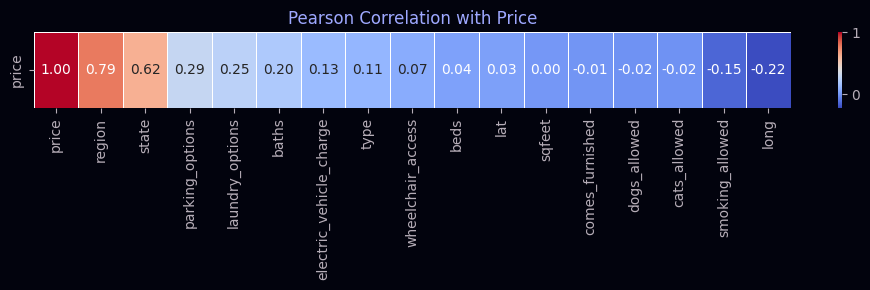

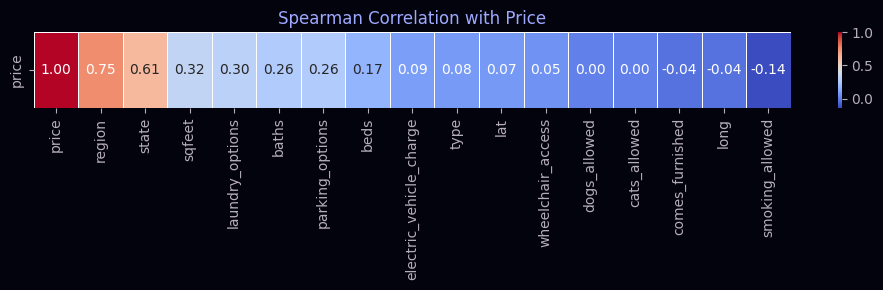

In [214]:
# Correlation heatmap with price only (after encoding)

cols = ["price", "sqfeet", "beds", "baths", "cats_allowed", "dogs_allowed",
        "smoking_allowed", "wheelchair_access", "electric_vehicle_charge",
        "comes_furnished", "lat", "long",
        "type", "laundry_options", "parking_options", "state", "region"]

df_heat = df_cleaned_region[cols].copy()

categorical_cols = ["type", "laundry_options", "parking_options", "state", "region"]
numeric_cols = [c for c in df_heat.columns if c not in categorical_cols + ["price"]]

X = df_heat.drop(columns=["price"]).copy()
y = df_heat["price"].copy()

# fill missing values
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0]).astype(str)

# target encode categorical columns
encoder = TargetEncoder(cols=categorical_cols)
X_enc = encoder.fit_transform(X, y)

# combine target + encoded features
df_enc = pd.concat([y, X_enc], axis=1)

# correlation with price only
corr_price_pearson = df_enc.corr(numeric_only=True)[["price"]].sort_values(by="price", ascending=False).T
corr_price_spearman = df_enc.corr(method="spearman", numeric_only=True)[["price"]].sort_values(by="price", ascending=False).T

def plot_correlation_heatmap(corr_matrix, title):
    plt.figure(figsize=(10, 3))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"{folder}/{title}.png") 
    plt.show()

plot_correlation_heatmap(corr_price_pearson, "Pearson Correlation with Price")
plot_correlation_heatmap(corr_price_spearman, "Spearman Correlation with Price")



In [104]:
display(summary_table(df_cleaned_region))

,Column,Data Type,Non-Null Count,Missing Values,Missing %,Num Categories
0,region,str,362781,0,0.000000,None
1,price,int64,362781,0,0.000000,None
2,type,str,362781,0,0.000000,None
3,sqfeet,int64,362781,0,0.000000,None
4,beds,int64,362781,0,0.000000,None
5,baths,float64,362781,0,0.000000,None
6,cats_allowed,int64,362781,0,0.000000,None
7,dogs_allowed,int64,362781,0,0.000000,None
8,smoking_allowed,int64,362781,0,0.000000,None
9,wheelchair_access,int64,362781,0,0.000000,None


In [105]:
#Task 3.3 : Constructing Data…
X = df_cleaned_region.drop(columns=[TARGET]).copy()
y = df_cleaned_region[TARGET].copy()

# ------------------------------
# 3) Train / test split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print("Shapes => X:", X.shape, "X_train:", X_train.shape, "X_test:", X_test.shape)

N_CLUSTERS = int(50*2.5)
coord_cols = ["lat", "long"]

coord_imputer = SimpleImputer(strategy="median")

train_coords = pd.DataFrame(
    coord_imputer.fit_transform(X_train[coord_cols]),
    columns=coord_cols,
    index=X_train.index
)

test_coords = pd.DataFrame(
    coord_imputer.transform(X_test[coord_cols]),
    columns=coord_cols,
    index=X_test.index
)

#print(train_coords)
#print(test_coords)

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
X_train["location_cluster"] = kmeans.fit_predict(train_coords).astype(str)
X_test["location_cluster"] = kmeans.predict(test_coords).astype(str)

Shapes => X: (362781, 16) X_train: (290224, 16) X_test: (72557, 16)


In [106]:
#Task 3.5 : Formatting Data…

# ------------------------------
# 5) Column groups
# ------------------------------
categorical_cols = [
    "type",
    "laundry_options",
    "parking_options",
    "state",
    "location_cluster",
    "region"
]

X_train_cat = X_train[categorical_cols].copy()
X_test_cat = X_test[categorical_cols].copy()

special_missing_cols = ["laundry_options", "parking_options"]

for col in categorical_cols:
    if col in special_missing_cols:
        X_train_cat[col] = X_train_cat[col].fillna("Missing").astype(str)
        X_test_cat[col] = X_test_cat[col].fillna("Missing").astype(str)
    else:
        most_freq = X_train_cat[col].mode()[0]
        X_train_cat[col] = X_train_cat[col].fillna(most_freq).astype(str)
        X_test_cat[col] = X_test_cat[col].fillna(most_freq).astype(str)

numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# ------------------------------
# 6) Minimal preprocessing
#    - numeric: median impute
#    - categorical: most_frequent impute
#    - then target encode categoricals
# ------------------------------
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train[numeric_cols]),
    columns=numeric_cols,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    num_imputer.transform(X_test[numeric_cols]),
    columns=numeric_cols,
    index=X_test.index
)

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train[numeric_cols]),
    columns=numeric_cols,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    num_imputer.transform(X_test[numeric_cols]),
    columns=numeric_cols,
    index=X_test.index
)

# categorical preprocessing
special_missing_cols = ["laundry_options", "parking_options"]
other_categorical_cols = [col for col in categorical_cols if col not in special_missing_cols]

# start from raw categorical columns
X_train_cat = X_train[categorical_cols].copy()
X_test_cat = X_test[categorical_cols].copy()

# keep missing as its own category for selected columns
for col in special_missing_cols:
    if col in X_train_cat.columns:
        X_train_cat[col] = X_train_cat[col].fillna("Missing")
        X_test_cat[col] = X_test_cat[col].fillna("Missing")

# most frequent imputation for the remaining categorical columns
if len(other_categorical_cols) > 0:
    X_train_cat[other_categorical_cols] = cat_imputer.fit_transform(X_train_cat[other_categorical_cols])
    X_test_cat[other_categorical_cols] = cat_imputer.transform(X_test_cat[other_categorical_cols])

# convert all categorical values to string
X_train_cat = X_train_cat.astype(str)
X_test_cat = X_test_cat.astype(str)


encoder = TargetEncoder(
    cols=categorical_cols,
    handle_missing="value",
    handle_unknown="value",
    smoothing=10
)

X_train_cat_enc = encoder.fit_transform(X_train_cat, y_train)
X_test_cat_enc = encoder.transform(X_test_cat)

# Final matrices
X_train_final = pd.concat([X_train_num, X_train_cat_enc], axis=1)
X_test_final = pd.concat([X_test_num, X_test_cat_enc], axis=1)

print("Final train shape:", X_train_final.shape)
print("Final test shape:", X_test_final.shape)
display(X_train_final.head())

Numeric columns: ['sqfeet', 'beds', 'baths', 'cats_allowed', 'dogs_allowed', 'smoking_allowed', 'wheelchair_access', 'electric_vehicle_charge', 'comes_furnished', 'lat', 'long']
Categorical columns: ['type', 'laundry_options', 'parking_options', 'state', 'location_cluster', 'region']
Final train shape: (290224, 17)
Final test shape: (72557, 17)


,sqfeet,beds,baths,cats_allowed,dogs_allowed,smoking_allowed,wheelchair_access,electric_vehicle_charge,comes_furnished,lat,long,type,laundry_options,parking_options,state,location_cluster,region
223309,1050.0,2.0,2.0,1.0,1.0,1.0,0.0,0.0,0.0,41.1377,-81.5539,1128.453147,1091.987916,1098.384394,839.860097,857.437950,832.474338
315486,850.0,2.0,1.5,1.0,1.0,0.0,0.0,0.0,0.0,33.9675,-98.6868,1128.453147,971.608600,1098.384394,975.039316,723.797425,757.877746
253848,1002.0,2.0,2.0,1.0,1.0,1.0,0.0,0.0,0.0,39.9695,-75.1396,1128.453147,1356.816412,1136.588796,1182.697915,1327.604478,1527.410901
126007,524.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,29.6252,-90.7623,1128.453147,1356.816412,1098.384394,901.530986,835.966470,845.793501
94989,755.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,38.6185,-90.2564,1128.453147,1024.319409,1136.588796,933.145648,893.249602,892.704142


# Task 4

In [107]:
#Task 4.1

def time_callable(func, name,*args, **kwargs):
    start_time = time.perf_counter()
    result = func(*args, **kwargs)
    duration = time.perf_counter() - start_time

    print(f"\ntraining took: {duration:.2f} seconds, {duration / 60:.0f}min:{duration%60:.1f}sec")
    #timestamp = time.strftime("%m_%d_%H_%M_%S", time.localtime())
    joblib.dump(result, f'{folder}/{name}_{timestamp}.pkl')
    return result, duration

# ------------------------------
# Models
# ------------------------------
rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

gb_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# ------------------------------
# XGBoost model
# ------------------------------
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [108]:
#Task 4.3

if ready_to_model == True:
    print("")
    # ------------------------------
    # 8) Train
    # ------------------------------
    print("Training Random Forest...")
    rf_model, _ = time_callable(rf_model.fit, 'rf_model', X_train_final, y_train)
    #rf_model.fit(X_train_final, y_train)

    print("Training Gradient Boosting...")
    gb_model, _ = time_callable(gb_model.fit, 'gb_model', X_train_final, y_train)
    #gb_model.fit(X_train_final, y_train)

    print("Training X Gradient Boosting...")
    xgb_model, _ = time_callable(xgb_model.fit, 'xgb_model', X_train_final, y_train)

    # ------------------------------
    # 9) Predict
    # ------------------------------
    rf_pred = rf_model.predict(X_test_final)
    gb_pred = gb_model.predict(X_test_final)
    xgb_pred = xgb_model.predict(X_test_final)
    


Training Random Forest...

training took: 359.95 seconds, 6min:59.9sec
Training Gradient Boosting...

training took: 250.31 seconds, 4min:10.3sec
Training X Gradient Boosting...

training took: 9.93 seconds, 0min:9.9sec


,Model,MAE,MSE,RMSE,R2,ASE,SSE,Observed Avg
0,Random Forest,62.709,18991.711,137.810,0.922,18991.711,1.377982e+09,1140.944
1,Gradient Boosting,150.683,48889.619,221.110,0.799,48889.619,3.547284e+09,1140.944
2,XGBoost,124.038,34441.906,185.585,0.858,34441.906,2.499001e+09,1140.944


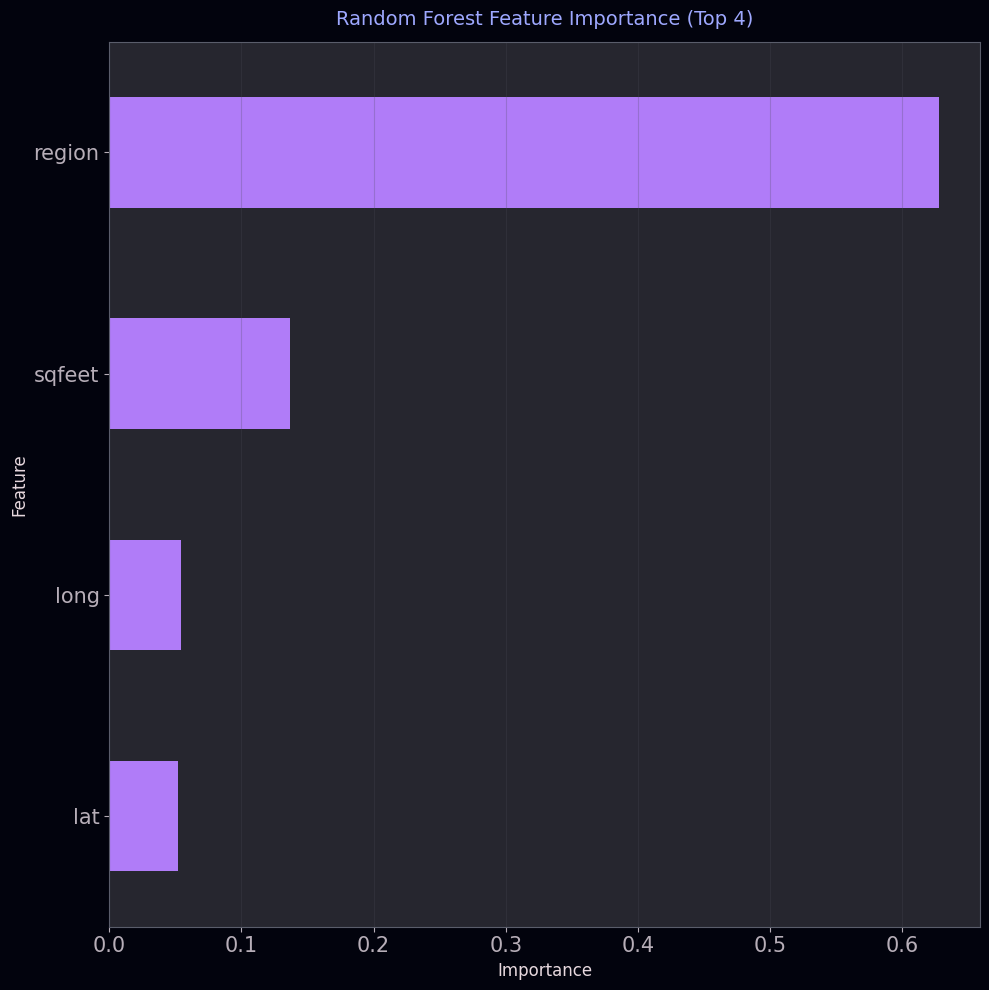

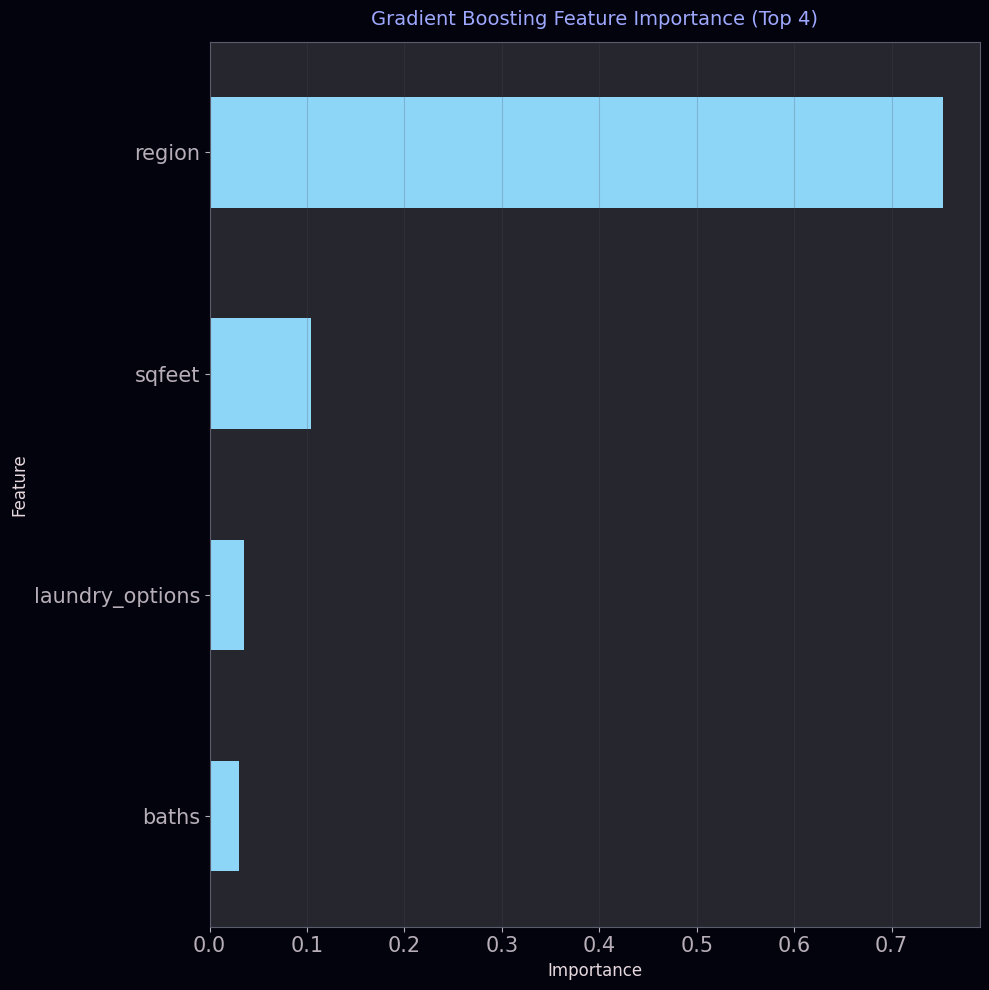

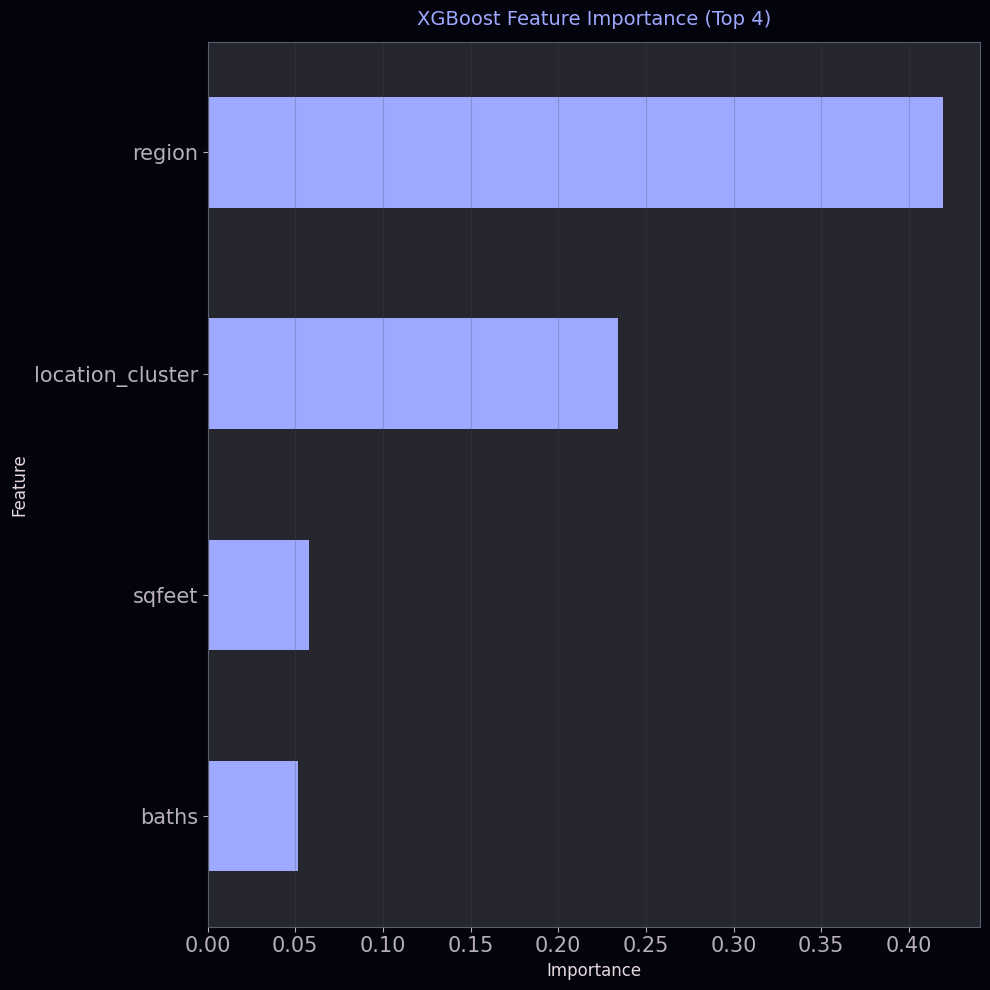

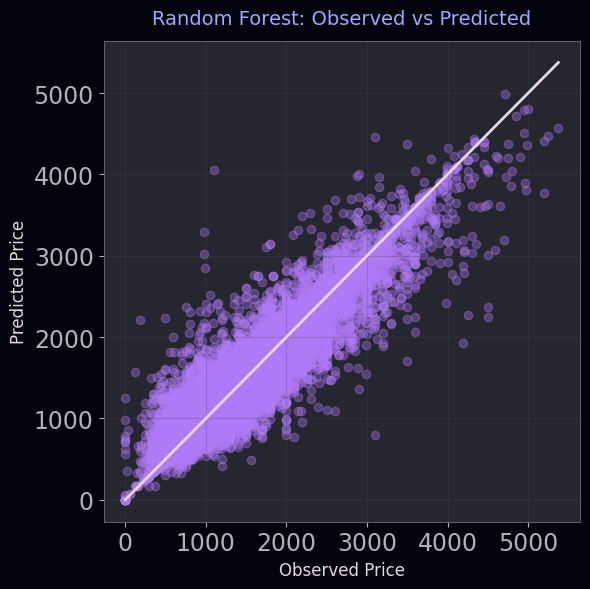

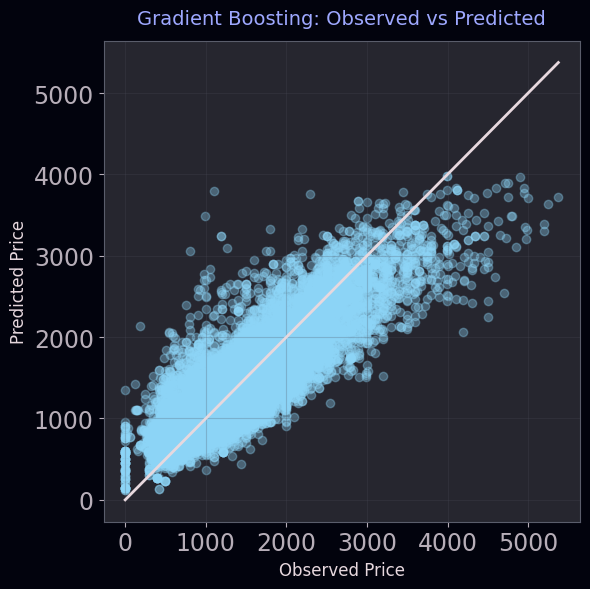

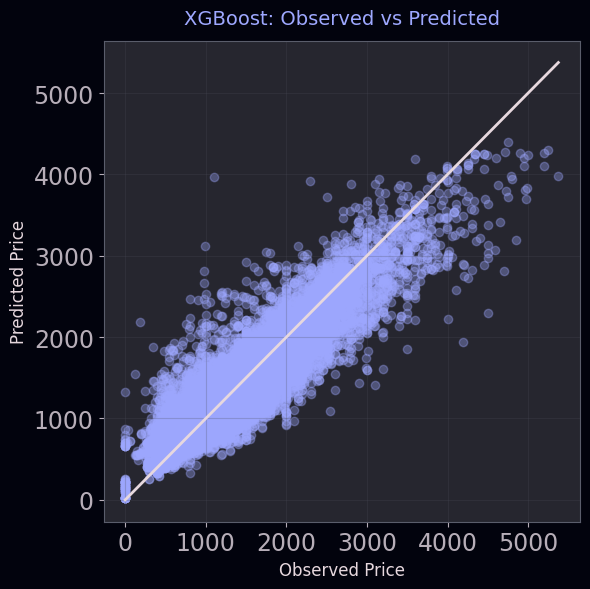

In [195]:
# ------------------------------
# 10) Metrics
# ------------------------------
def get_model_metrics(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    ase = mse
    sse = np.sum((y_true - y_pred) ** 2)
    observed_avg = np.mean(y_true)

    return {
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "ASE": ase,
        "SSE": sse,
        "Observed Avg": observed_avg
    }

# Build results DataFrame
results_df = pd.DataFrame([
    get_model_metrics("Random Forest", y_test, rf_pred),
    get_model_metrics("Gradient Boosting", y_test, gb_pred),
    get_model_metrics("XGBoost", y_test, xgb_pred)
])

display(results_df.round(3))

# ------------------------------
# 11) Feature importance plots
#     No one-hot split problem here:
#     each original categorical column stays one encoded column
# ------------------------------
feature_names = X_train_final.columns.tolist()

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

gb_importance = pd.Series(
    gb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)


top_n = 4#8

def styled_barh(series, title, bar_color):
    fig, ax = plt.subplots(figsize=(10, 10), facecolor=theme["figure_bg"])
    ax.set_facecolor(theme["axes_bg"])

    series.head(top_n).sort_values().plot(
        kind="barh",
        ax=ax,
        color=bar_color,
        width = 0.5
    )

    #title = title.replace("_", "\n").replace(" ", "\n")
    ax.set_title(title, color=theme["lavender"], pad=12, fontsize=14)
    ax.set_xlabel("Importance", color=theme["text"], fontsize=12)
    ax.set_ylabel("Feature", color=theme["text"], fontsize=12)
    ax.tick_params(colors=theme["muted"], labelsize=15)
    ax.grid(axis="x", color=theme["grid"], alpha=0.25)

    for spine in ax.spines.values():
        spine.set_color(theme["spine"])

    plt.tight_layout()
    plt.savefig(f"{folder}/{title}.png") 
    plt.show()


def styled_barh_1(series, title, bar_color):
    s = series.head(top_n).sort_values()

    bar_height = 0.2
    spacing = 0.05
    step = bar_height + spacing

    y = np.arange(len(s)) * step

    fig, ax = plt.subplots(figsize=(10, 10), facecolor=theme["figure_bg"])
    ax.set_facecolor(theme["axes_bg"])

    ax.barh(
        y,
        s.values,
        height=bar_height,
        color=bar_color
    )

    ax.set_yticks(y)
    ax.set_yticklabels(s.index)

    ax.set_title(title, color=theme["lavender"], pad=12)
    ax.set_xlabel("Importance", color=theme["text"])
    ax.set_ylabel("Feature", color=theme["text"])
    ax.tick_params(colors=theme["muted"], labelsize=15)
    ax.grid(axis="x", color=theme["grid"], alpha=0.25)

    for spine in ax.spines.values():
        spine.set_color(theme["spine"])

    plt.tight_layout()
    plt.show()

styled_barh(rf_importance, f"Random Forest Feature Importance (Top {top_n})", theme["purple"])
styled_barh(gb_importance, f"Gradient Boosting Feature Importance (Top {top_n})", theme["blue"])
styled_barh(xgb_importance, f"XGBoost Feature Importance (Top {top_n})", theme["lavender"])


#display(rf_importance.to_frame("RF_Importance").head(20))
#display(gb_importance.to_frame("GB_Importance").head(20))
#display(xgb_importance.to_frame("XGB_Importance").head(20))

# ------------------------------
# 12) Optional: observed vs predicted
# ------------------------------
def styled_observed_vs_pred(y_true, y_pred, title, point_color):
    fig, ax = plt.subplots(figsize=(6, 6), facecolor=theme["figure_bg"])
    ax.set_facecolor(theme["axes_bg"])

    ax.scatter(y_true, y_pred, alpha=0.35, color=point_color)
    ax.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        color=theme["text"],
        linewidth=2
    )

    ax.set_xlabel("Observed Price", color=theme["text"], fontsize=12)
    ax.set_ylabel("Predicted Price", color=theme["text"], fontsize=12)
    ax.set_title(title, color=theme["lavender"], pad=12, fontsize=14)
    ax.tick_params(colors=theme["muted"], labelsize=17)
    ax.grid(True, color=theme["grid"], alpha=0.25)

    for spine in ax.spines.values():
        spine.set_color(theme["spine"])

    plt.tight_layout()
    plt.savefig(f"{folder}/{title}.png") 
    plt.show()


styled_observed_vs_pred(y_test, rf_pred, "Random Forest: Observed vs Predicted", theme["purple"])
styled_observed_vs_pred(y_test, gb_pred, "Gradient Boosting: Observed vs Predicted", theme["blue"])
styled_observed_vs_pred(y_test, xgb_pred, "XGBoost: Observed vs Predicted", theme["lavender"])

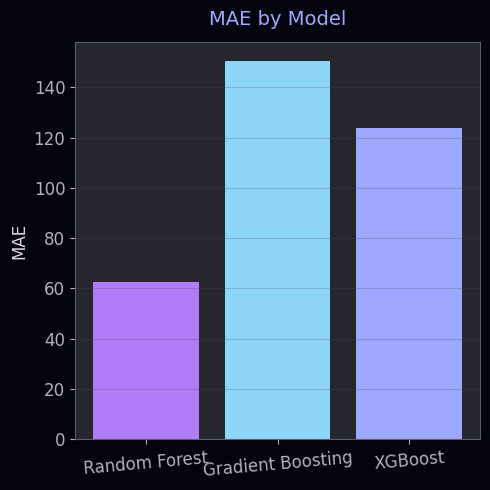

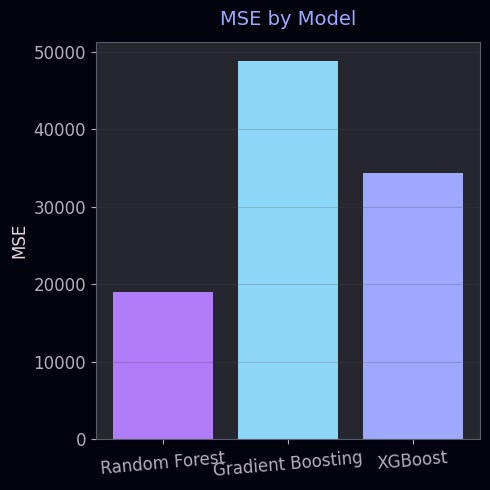

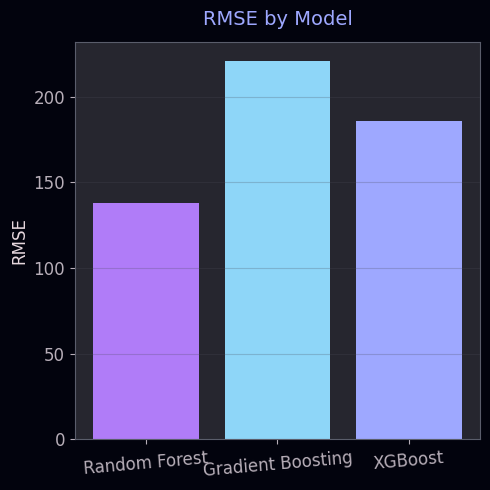

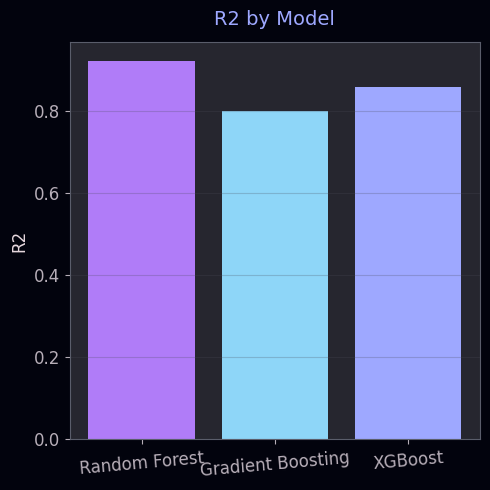

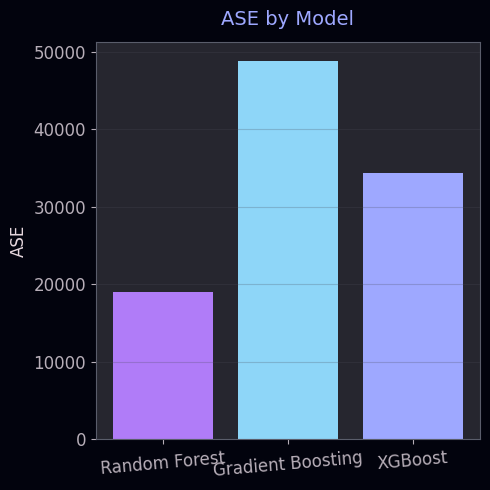

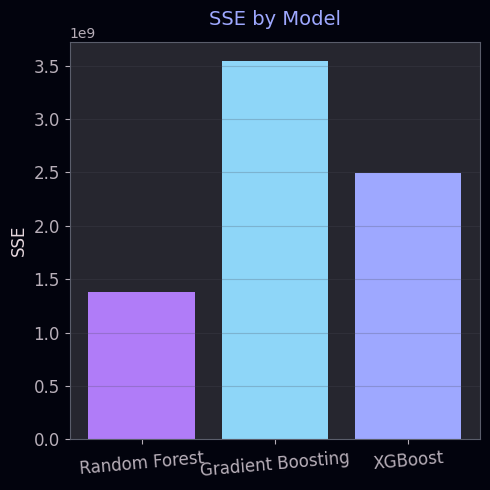

In [203]:




metrics_to_plot = ["MAE", "MSE", "RMSE", "R2", "ASE", "SSE"]

bar_colors = [theme["purple"], theme["blue"], theme["lavender"]]

for metric in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(5, 5), facecolor=theme["figure_bg"])
    ax.set_facecolor(theme["axes_bg"])

    colors = [bar_colors[i % len(bar_colors)] for i in range(len(results_df))]

    ax.bar(
        results_df["Model"],
        results_df[metric],
        color=colors
    )

    ax.set_title(f"{metric} by Model", color=theme["lavender"], pad=12, fontsize=14)
    #ax.set_xlabel("Model", color=theme["text"], fontsize=12)
    ax.set_ylabel(metric, color=theme["text"], fontsize=12)
    ax.tick_params(axis="x", colors=theme["muted"], rotation=5, labelsize=12)
    ax.tick_params(axis="y", colors=theme["muted"], labelsize=12)
    ax.grid(axis="y", color=theme["grid"], alpha=0.25)

    for spine in ax.spines.values():
        spine.set_color(theme["spine"])

    plt.tight_layout()
    plt.savefig(f"{folder}/{metric} by Model.png") 
    plt.show()

/home/gordon/Documents/MonU/MonU/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


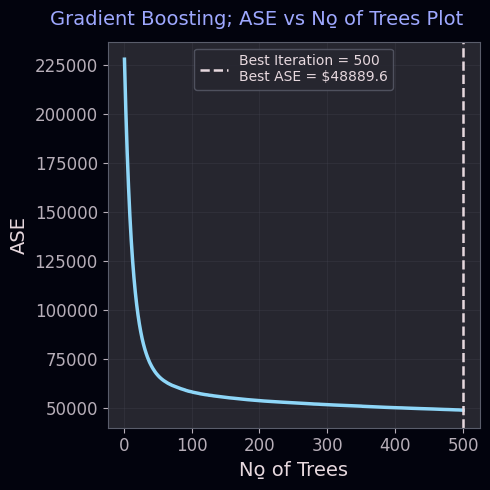

Gradient Boosting best iteration: 500
Gradient Boosting best ASE: 48,889.6187


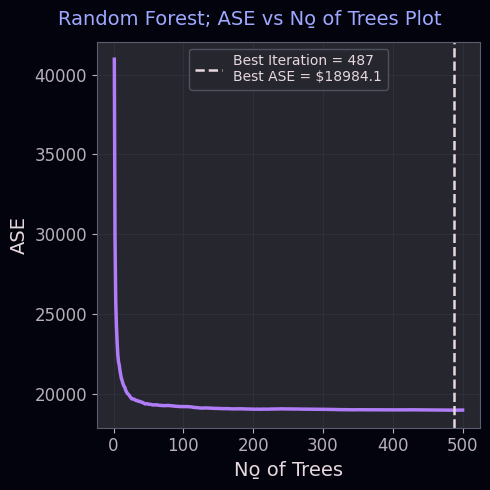

Random Forest best number of trees on test curve: 487
Random Forest best ASE: 18,984.0664


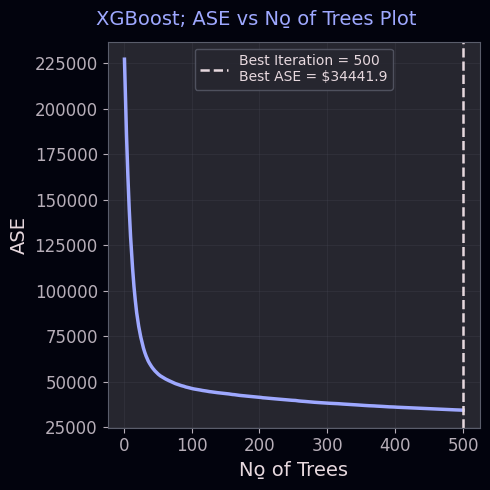

Best number of trees: 500
Best ASE: 34,441.9062


In [210]:
def styled_iteration_plot(x, y, title, best, line_color):
    fig, ax = plt.subplots(figsize=(5, 5), facecolor=theme["figure_bg"])
    ax.set_facecolor(theme["axes_bg"])

    ax.plot(x, y, color=line_color, linewidth=2.5)
    ax.axvline(
        best[0],
        color=theme["text"],
        linestyle="--",
        linewidth=1.8,
        label=f"Best Iteration = {best[0]} \nBest ASE = ${best[1].round(1)}"

    )

    ax.set_xlabel("No̱ of Trees", color=theme["text"], fontsize=14)
    ax.set_ylabel("ASE", color=theme["text"], fontsize=14)
    ax.set_title(title, color=theme["lavender"], pad=12 , fontsize=14).set_x(0.4)
    ax.tick_params(axis="x", colors=theme["muted"], labelsize=12)
    ax.tick_params(axis="y", colors=theme["muted"], labelsize=12)
    ax.grid(True, color=theme["grid"], alpha=0.25)

    for spine in ax.spines.values():
        spine.set_color(theme["spine"])

    legend = ax.legend(facecolor=theme["axes_bg"], edgecolor=theme["spine"])
    for text in legend.get_texts():
        text.set_color(theme["text"])

    plt.tight_layout()
    plt.savefig(f"{folder}/{title}_2.png")
    plt.show()


# ------------------------------
# 14) Iteration / Error plots
# ------------------------------
X_test_np = X_test_final.to_numpy()
# ---------- 14A. Gradient Boosting Iteration Plot ----------
gb_ase = []

for y_pred_stage in gb_model.staged_predict(X_test_np):
    ase = mean_squared_error(y_test, y_pred_stage)
    gb_ase.append(ase)

gb_best_iter = np.argmin(gb_ase) + 1
gb_best_ase = np.min(gb_ase)

styled_iteration_plot(
    x=range(1, len(gb_ase) + 1),
    y=gb_ase,
    title="Gradient Boosting; ASE vs No̱ of Trees Plot",
    best=[gb_best_iter, gb_best_ase],
    line_color=theme["blue"]
)
#"Gradient Boosting Iteration Plot (ASE vs № No̱ Nº, No̱, or no of Trees)"
print(f"Gradient Boosting best iteration: {gb_best_iter}")
print(f"Gradient Boosting best ASE: {gb_best_ase:,.4f}")


# ---------- 14B. Random Forest Error Plot ----------
rf_ase = []
rf_running_pred = np.zeros(len(X_test_np), dtype=float)

for i, tree in enumerate(rf_model.estimators_, start=1):
    tree_pred = tree.predict(X_test_np)
    rf_running_pred += tree_pred

    rf_avg_pred = rf_running_pred / i
    ase = mean_squared_error(y_test, rf_avg_pred)
    rf_ase.append(ase)

rf_best_trees = np.argmin(rf_ase) + 1
rf_best_ase = np.min(rf_ase)

styled_iteration_plot(
    x=range(1, len(rf_ase) + 1),
    y=rf_ase,
    title="Random Forest; ASE vs No̱ of Trees Plot",
    best=[rf_best_trees, rf_best_ase],
    line_color=theme["purple"]
)

print(f"Random Forest best number of trees on test curve: {rf_best_trees}")
print(f"Random Forest best ASE: {rf_best_ase:,.4f}")


# ---------- 14C. XGBoost Iteration Plot ----------
xgb_ase = []

if hasattr(xgb_model, "best_iteration") and xgb_model.best_iteration is not None:
    max_trees = xgb_model.best_iteration + 1
else:
    max_trees = xgb_model.n_estimators

for i in range(1, max_trees + 1):
    y_pred_i = xgb_model.predict(X_test_np, iteration_range=(0, i))
    ase_i = mean_squared_error(y_test, y_pred_i)
    xgb_ase.append(ase_i)

best_trees = np.argmin(xgb_ase) + 1
best_ase = np.min(xgb_ase)

styled_iteration_plot(
    x=range(1, max_trees + 1),
    y=xgb_ase,
    title="XGBoost; ASE vs No̱ of Trees Plot",
    best=[best_trees, best_ase],
    line_color=theme["lavender"]
)

print(f"Best number of trees: {best_trees}")
print(f"Best ASE: {best_ase:,.4f}")

# Nothing to See below here, some checks and tests

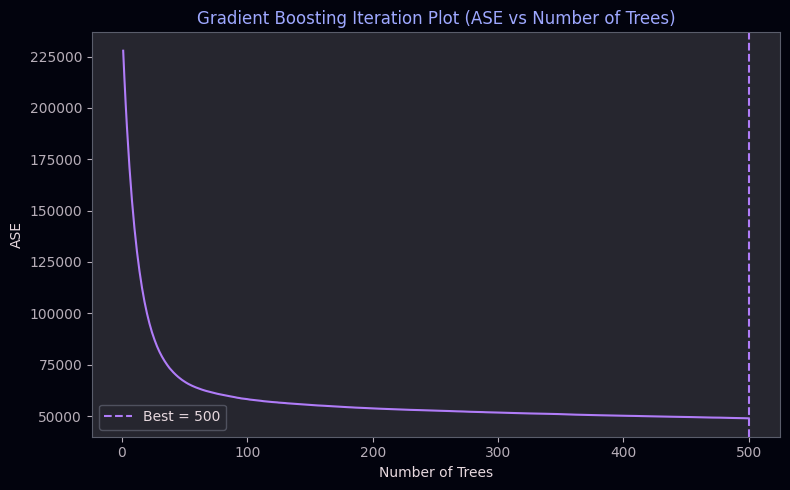

Gradient Boosting best iteration: 500
Gradient Boosting best ASE: 48,889.6187


/home/gordon/Documents/MonU/MonU/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/home/gordon/Documents/MonU/MonU/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/home/gordon/Documents/MonU/MonU/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/home/gordon/Documents/MonU/MonU/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/home/gordon/Documents/MonU/MonU/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without f

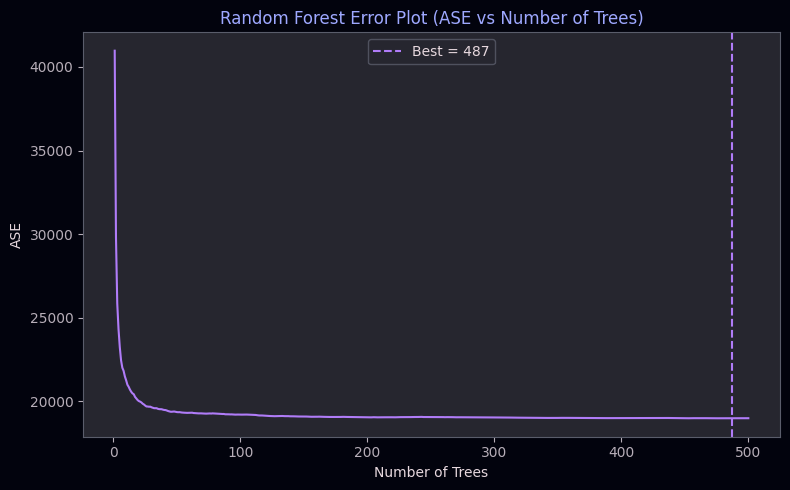

Random Forest best number of trees on test curve: 487
Random Forest best ASE: 18,984.0664


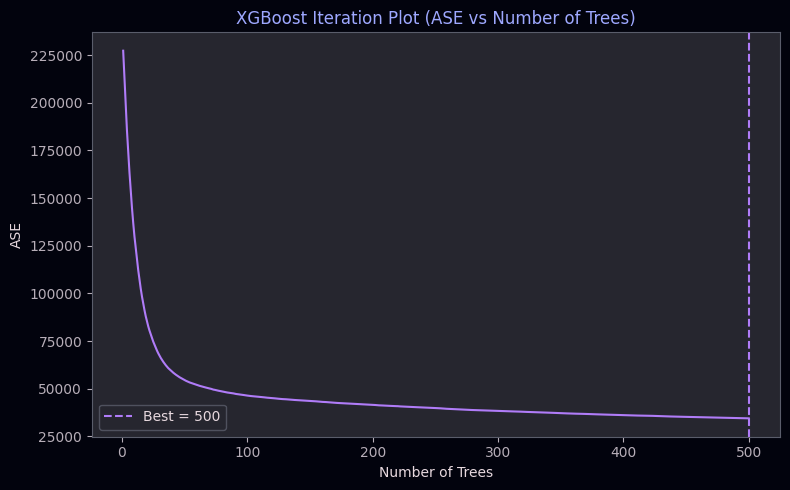

Best number of trees: 500
Best ASE: 34,441.9062


In [198]:
# ------------------------------
# 14) Iteration / Error plots
#     Gradient Boosting: ASE vs Number of Trees
#     Random Forest:     ASE vs Number of Trees
# ------------------------------



# ---------- 14A. Gradient Boosting Iteration Plot ----------
gb_ase = []

for y_pred_stage in gb_model.staged_predict(X_test_final):
    ase = mean_squared_error(y_test, y_pred_stage)   # ASE = average squared error
    gb_ase.append(ase)

gb_best_iter = np.argmin(gb_ase) + 1
gb_best_ase = np.min(gb_ase)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(gb_ase) + 1), gb_ase)
plt.axvline(gb_best_iter, linestyle="--", label=f"Best = {gb_best_iter}")
plt.xlabel("Number of Trees")
plt.ylabel("ASE")
plt.title("Gradient Boosting Iteration Plot (ASE vs Number of Trees)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Gradient Boosting best iteration: {gb_best_iter}")
print(f"Gradient Boosting best ASE: {gb_best_ase:,.4f}")


# ---------- 14B. Random Forest Error Plot ----------
# Build cumulative forest prediction:
# prediction with first tree, first 2 trees averaged, first 3 trees averaged, etc.

rf_ase = []
rf_running_pred = np.zeros(len(X_test_final), dtype=float)

for i, tree in enumerate(rf_model.estimators_, start=1):
    tree_pred = tree.predict(X_test_final)
    rf_running_pred += tree_pred

    rf_avg_pred = rf_running_pred / i
    ase = mean_squared_error(y_test, rf_avg_pred)
    rf_ase.append(ase)

rf_best_trees = np.argmin(rf_ase) + 1
rf_best_ase = np.min(rf_ase)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(rf_ase) + 1), rf_ase)
plt.axvline(rf_best_trees, linestyle="--", label=f"Best = {rf_best_trees}")
plt.xlabel("Number of Trees")
plt.ylabel("ASE")
plt.title("Random Forest Error Plot (ASE vs Number of Trees)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Random Forest best number of trees on test curve: {rf_best_trees}")
print(f"Random Forest best ASE: {rf_best_ase:,.4f}")

# ------------------------------
# XGBoost Iteration Plot
# ASE vs Number of Trees
# ------------------------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

xgb_ase = []

# if you used early stopping, prefer best_iteration + 1
if hasattr(xgb_model, "best_iteration") and xgb_model.best_iteration is not None:
    max_trees = xgb_model.best_iteration + 1
else:
    max_trees = xgb_model.n_estimators

for i in range(1, max_trees + 1):
    y_pred_i = xgb_model.predict(X_test_final, iteration_range=(0, i))
    ase_i = mean_squared_error(y_test, y_pred_i)
    xgb_ase.append(ase_i)

best_trees = np.argmin(xgb_ase) + 1
best_ase = np.min(xgb_ase)

plt.figure(figsize=(8, 5))
plt.plot(range(1, max_trees + 1), xgb_ase)
plt.axvline(best_trees, linestyle="--", label=f"Best = {best_trees}")
plt.xlabel("Number of Trees")
plt.ylabel("ASE")
plt.title("XGBoost Iteration Plot (ASE vs Number of Trees)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best number of trees: {best_trees}")
print(f"Best ASE: {best_ase:,.4f}")


In [199]:
def find_value(df, value):
    mask = df.astype(str).eq(value)
    found = mask.any().any()
    rows = df[mask.any(axis=1)]
    locations = list(mask.stack()[lambda x: x].index)

    print(found)
    print(rows)
    print(locations)
    return found, rows, locations

find_value(X_train_final, "value")
find_value(X_test_final, "value")
find_value(X_train_final, "Missing")
find_value(X_test_final, "Missing")

False
Empty DataFrame
Columns: [sqfeet, beds, baths, cats_allowed, dogs_allowed, smoking_allowed, wheelchair_access, electric_vehicle_charge, comes_furnished, lat, long, type, laundry_options, parking_options, state, location_cluster, region]
Index: []
[]
False
Empty DataFrame
Columns: [sqfeet, beds, baths, cats_allowed, dogs_allowed, smoking_allowed, wheelchair_access, electric_vehicle_charge, comes_furnished, lat, long, type, laundry_options, parking_options, state, location_cluster, region]
Index: []
[]
False
Empty DataFrame
Columns: [sqfeet, beds, baths, cats_allowed, dogs_allowed, smoking_allowed, wheelchair_access, electric_vehicle_charge, comes_furnished, lat, long, type, laundry_options, parking_options, state, location_cluster, region]
Index: []
[]
False
Empty DataFrame
Columns: [sqfeet, beds, baths, cats_allowed, dogs_allowed, smoking_allowed, wheelchair_access, electric_vehicle_charge, comes_furnished, lat, long, type, laundry_options, parking_options, state, location_cluste

(np.False_,
 Empty DataFrame
 Columns: [sqfeet, beds, baths, cats_allowed, dogs_allowed, smoking_allowed, wheelchair_access, electric_vehicle_charge, comes_furnished, lat, long, type, laundry_options, parking_options, state, location_cluster, region]
 Index: [],
 [])

In [200]:
cutoffs = {
    "price": (1, max(df["price"])),
    "sqfeet": (70, max(df["sqfeet"]))
}

outlier_counts = check_outliers_multiple(df_cleaned, cutoffs)
print(outlier_counts)

print(f"These properties represent {(outlier_counts['total'] / start_size) * 100:.2f}% of the dataset.")


{'price': 1299, 'sqfeet': 924, 'total': 2223}
These properties represent 0.58% of the dataset.
